In [70]:

import pandas as pd
import matplotlib as plt
import shap
import glob as glob
import numpy as np

from streamlit import columns

In [71]:
path = r'C:\Users\hkute\Documents\LearningPython\tennis_predictor\Tennis_Predictor\datasets'

all_files = glob.glob(path + r"\atp_matches_*.csv")

df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

pd.set_option('display.max_columns', None)

df.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2003-1536,Madrid Masters,Hard,48,M,20031013,1,101965,NaN,NaN,Wayne Ferreira,R,185.0,RSA,32.0,103344,NaN,NaN,Ivan Ljubicic,R,193.0,CRO,24.5,7-6(7) 7-6(5),3,R64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,1090.0,42.0,865.0
1,2003-1536,Madrid Masters,Hard,48,M,20031013,2,102358,NaN,Q,Thomas Enqvist,R,190.0,SWE,29.5,102338,NaN,NaN,Yevgeny Kafelnikov,R,190.0,RUS,29.6,6-3 RET,3,R64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,146.0,258.0,40.0,950.0
2,2003-1536,Madrid Masters,Hard,48,M,20031013,3,102998,NaN,Q,Jan Michael Gambill,R,190.0,USA,26.3,103786,NaN,NaN,Nikolay Davydenko,R,178.0,RUS,22.3,6-3 6-3,3,R64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.0,660.0,43.0,855.0
3,2003-1536,Madrid Masters,Hard,48,M,20031013,4,102610,NaN,NaN,Albert Costa,R,180.0,ESP,28.3,103602,NaN,NaN,Fernando Gonzalez,R,183.0,CHI,23.2,6-3 7-6(3),3,R64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0,1170.0,22.0,1190.0
4,2003-1536,Madrid Masters,Hard,48,M,20031013,5,102374,NaN,WC,Alex Corretja,R,180.0,ESP,29.5,104745,NaN,WC,Rafael Nadal,L,185.0,ESP,17.3,6-2 3-6 6-4,3,R64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127.0,290.0,49.0,788.0


In [72]:
df.drop(['winner_seed', 'loser_seed','loser_entry', 'winner_entry'], axis=1, inplace=True)
df = df.fillna(df.mean(numeric_only=True))
df

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2003-1536,Madrid Masters,Hard,48,M,20031013,1,101965,Wayne Ferreira,R,185.000000,RSA,32.0,103344,Ivan Ljubicic,R,193.000000,CRO,24.500000,7-6(7) 7-6(5),3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,28.0,1090.0,42.000000,865.000000
1,2003-1536,Madrid Masters,Hard,48,M,20031013,2,102358,Thomas Enqvist,R,190.000000,SWE,29.5,102338,Yevgeny Kafelnikov,R,190.000000,RUS,29.600000,6-3 RET,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,146.0,258.0,40.000000,950.000000
2,2003-1536,Madrid Masters,Hard,48,M,20031013,3,102998,Jan Michael Gambill,R,190.000000,USA,26.3,103786,Nikolay Davydenko,R,178.000000,RUS,22.300000,6-3 6-3,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,57.0,660.0,43.000000,855.000000
3,2003-1536,Madrid Masters,Hard,48,M,20031013,4,102610,Albert Costa,R,180.000000,ESP,28.3,103602,Fernando Gonzalez,R,183.000000,CHI,23.200000,6-3 7-6(3),3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,23.0,1170.0,22.000000,1190.000000
4,2003-1536,Madrid Masters,Hard,48,M,20031013,5,102374,Alex Corretja,R,180.000000,ESP,29.5,104745,Rafael Nadal,L,185.000000,ESP,17.300000,6-2 3-6 6-4,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,127.0,290.0,49.000000,788.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436092,2024-8268,Yokkaichi CH,Hard,32,C,20241125,342,122352,Christoph Negritu,R,193.000000,GER,30.6,206923,Shinji Hazawa,R,175.000000,JPN,25.600000,7-5 6-3,3,Q1,95.000000,5.000000,1.000000,68.000000,39.000000,25.000000,19.000000,11.000000,3.000000,5.000000,0.000000,0.000000,73.000000,54.00000,29.000000,9.000000,10.000000,5.000000,9.000000,409.0,113.0,1073.000000,11.000000
436093,2024-8268,Yokkaichi CH,Hard,32,C,20241125,341,207987,Ryuki Matsuda,R,157.000000,JPN,24.9,200665,Yuta Kawahashi,R,175.000000,JPN,26.800000,6-4 6-0,3,Q1,69.000000,1.000000,0.000000,51.000000,28.000000,20.000000,16.000000,8.000000,5.000000,5.000000,0.000000,1.000000,54.000000,31.00000,16.000000,10.000000,8.000000,4.000000,8.000000,507.0,76.0,860.000000,22.000000
436094,2024-8268,Yokkaichi CH,Hard,32,C,20241125,340,209951,Petr Bar Biryukov,L,196.000000,RUS,22.7,202356,Tsung Hao Huang,R,173.000000,TPE,25.000000,6-4 6-3,3,Q1,67.000000,4.000000,2.000000,62.000000,35.000000,28.000000,7.000000,9.000000,5.000000,8.000000,0.000000,5.000000,66.000000,41.00000,22.000000,8.000000,10.000000,4.000000,10.000000,429.0,100.0,708.000000,40.000000
436095,2024-8268,Yokkaichi CH,Hard,32,C,20241125,338,202113,Hikaru Shiraishi,R,168.000000,JPN,24.5,211627,Hayato Matsuoka,R,180.000000,JPN,19.800000,7-6(6) 3-6 6-4,3,Q1,180.000000,1.000000,2.000000,93.000000,53.000000,29.000000,22.000000,15.000000,2.000000,7.000000,2.000000,1.000000,117.000000,68.00000,41.000000,23.000000,16.000000,7.000000,12.000000,528.0,71.0,894.000000,20.000000


In [73]:
# one hot encoding surface
surface = pd.get_dummies(df.surface, dtype=int)

df = pd.concat([df, surface], axis='columns')
df.drop(["surface"], axis='columns', inplace=True)

df

,tourney_id,tourney_name,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,Carpet,Clay,Grass,Hard
0,2003-1536,Madrid Masters,48,M,20031013,1,101965,Wayne Ferreira,R,185.000000,RSA,32.0,103344,Ivan Ljubicic,R,193.000000,CRO,24.500000,7-6(7) 7-6(5),3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,28.0,1090.0,42.000000,865.000000,0,0,0,1
1,2003-1536,Madrid Masters,48,M,20031013,2,102358,Thomas Enqvist,R,190.000000,SWE,29.5,102338,Yevgeny Kafelnikov,R,190.000000,RUS,29.600000,6-3 RET,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,146.0,258.0,40.000000,950.000000,0,0,0,1
2,2003-1536,Madrid Masters,48,M,20031013,3,102998,Jan Michael Gambill,R,190.000000,USA,26.3,103786,Nikolay Davydenko,R,178.000000,RUS,22.300000,6-3 6-3,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,57.0,660.0,43.000000,855.000000,0,0,0,1
3,2003-1536,Madrid Masters,48,M,20031013,4,102610,Albert Costa,R,180.000000,ESP,28.3,103602,Fernando Gonzalez,R,183.000000,CHI,23.200000,6-3 7-6(3),3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,23.0,1170.0,22.000000,1190.000000,0,0,0,1
4,2003-1536,Madrid Masters,48,M,20031013,5,102374,Alex Corretja,R,180.000000,ESP,29.5,104745,Rafael Nadal,L,185.000000,ESP,17.300000,6-2 3-6 6-4,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,127.0,290.0,49.000000,788.000000,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436092,2024-8268,Yokkaichi CH,32,C,20241125,342,122352,Christoph Negritu,R,193.000000,GER,30.6,206923,Shinji Hazawa,R,175.000000,JPN,25.600000,7-5 6-3,3,Q1,95.000000,5.000000,1.000000,68.000000,39.000000,25.000000,19.000000,11.000000,3.000000,5.000000,0.000000,0.000000,73.000000,54.00000,29.000000,9.000000,10.000000,5.000000,9.000000,409.0,113.0,1073.000000,11.000000,0,0,0,1
436093,2024-8268,Yokkaichi CH,32,C,20241125,341,207987,Ryuki Matsuda,R,157.000000,JPN,24.9,200665,Yuta Kawahashi,R,175.000000,JPN,26.800000,6-4 6-0,3,Q1,69.000000,1.000000,0.000000,51.000000,28.000000,20.000000,16.000000,8.000000,5.000000,5.000000,0.000000,1.000000,54.000000,31.00000,16.000000,10.000000,8.000000,4.000000,8.000000,507.0,76.0,860.000000,22.000000,0,0,0,1
436094,2024-8268,Yokkaichi CH,32,C,20241125,340,209951,Petr Bar Biryukov,L,196.000000,RUS,22.7,202356,Tsung Hao Huang,R,173.000000,TPE,25.000000,6-4 6-3,3,Q1,67.000000,4.000000,2.000000,62.000000,35.000000,28.000000,7.000000,9.000000,5.000000,8.000000,0.000000,5.000000,66.000000,41.00000,22.000000,8.000000,10.000000,4.000000,10.000000,429.0,100.0,708.000000,40.000000,0,0,0,1
436095,2024-8268,Yokkaichi CH,32,C,20241125,338,202113,Hikaru Shiraishi,R,168.000000,JPN,24.5,211627,Hayato Matsuoka,R,180.000000,JPN,19.800000,7-6(6) 3-6 6-4,3,Q1,180.000000,1.000000,2.000000,93.000000,53.000000,29.000000,22.000000,15.000000,2.000000,7.000000,2.000000,1.000000,117.000000,68.00000,41.000000,23.000000,16.000000,7.00000

In [74]:
df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d')

historical_df = df[df['tourney_date'] < "2023-01-01"]
future_df = df[df['tourney_date'] >= "2023-01-01"]

historical_df.head()

,tourney_id,tourney_name,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,Carpet,Clay,Grass,Hard
0,2003-1536,Madrid Masters,48,M,2003-10-13,1,101965,Wayne Ferreira,R,185.0,RSA,32.0,103344,Ivan Ljubicic,R,193.0,CRO,24.5,7-6(7) 7-6(5),3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,28.0,1090.0,42.0,865.0,0,0,0,1
1,2003-1536,Madrid Masters,48,M,2003-10-13,2,102358,Thomas Enqvist,R,190.0,SWE,29.5,102338,Yevgeny Kafelnikov,R,190.0,RUS,29.6,6-3 RET,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,146.0,258.0,40.0,950.0,0,0,0,1
2,2003-1536,Madrid Masters,48,M,2003-10-13,3,102998,Jan Michael Gambill,R,190.0,USA,26.3,103786,Nikolay Davydenko,R,178.0,RUS,22.3,6-3 6-3,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,57.0,660.0,43.0,855.0,0,0,0,1
3,2003-1536,Madrid Masters,48,M,2003-10-13,4,102610,Albert Costa,R,180.0,ESP,28.3,103602,Fernando Gonzalez,R,183.0,CHI,23.2,6-3 7-6(3),3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,23.0,1170.0,22.0,1190.0,0,0,0,1
4,2003-1536,Madrid Masters,48,M,2003-10-13,5,102374,Alex Corretja,R,180.0,ESP,29.5,104745,Rafael Nadal,L,185.0,ESP,17.3,6-2 3-6 6-4,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,127.0,290.0,49.0,788.0,0,0,0,1


In [75]:
winner_rename = {
    'winner_hand': 'player_hand', 'loser_hand': 'opponent_hand',
    'winner_ht': 'player_ht', 'loser_ht': 'opponent_ht',
    'winner_age': 'player_age', 'loser_age': 'opponent_age',
    'winner_rank': 'player_rank', 'loser_rank': 'opponent_rank',
    'winner_rank_points': 'player_rank_points', 'loser_rank_points': 'opponent_rank_points',
    'winner_name': 'player_name', 'loser_name': 'opponent_name',
    'winner_id': 'player_id', 'loser_id': 'opponent_id',
    'winner_ioc': 'player_ioc', 'loser_ioc': 'opponent_ioc',
}

loser_rename = {
    'loser_hand': 'player_hand', 'winner_hand': 'opponent_hand',
    'loser_ht': 'player_ht', 'winner_ht': 'opponent_ht',
    'loser_age': 'player_age', 'winner_age': 'opponent_age',
    'loser_rank': 'player_rank', 'winner_rank': 'opponent_rank',
    'loser_rank_points': 'player_rank_points', 'winner_rank_points': 'opponent_rank_points',
    'loser_name': 'player_name', 'winner_name': 'opponent_name',
    'loser_id': 'player_id', 'winner_id': 'opponent_id',
    'loser_ioc': 'player_ioc', 'winner_ioc': 'opponent_ioc',
}

winner = historical_df.copy()
winner.columns = [col.replace('w_', 'player_') if col.startswith('w_')
                  else col.replace('l_','opponent_') if col.startswith('l_')
                  else col
                  for col in winner.columns
                  ]
winner = winner.rename(columns=winner_rename)
winner['label'] = 1

loser = historical_df.copy()
loser.columns = [col.replace('l_', 'player_') if col.startswith('l_')
                else col.replace('w_','opponent_') if col.startswith('w_')
                else col
                for col in loser.columns
                 ]
loser = loser.rename(columns=loser_rename)
loser['label'] = 0


matches_df = pd.concat([winner,loser], ignore_index=True)
matches_df

,tourney_id,tourney_name,draw_size,tourney_level,tourney_date,match_num,player_id,player_name,player_hand,player_ht,player_ioc,player_age,opponent_id,opponent_name,opponent_hand,opponent_ht,opponent_ioc,opponent_age,score,best_of,round,minutes,player_ace,player_df,player_svpt,player_1stIn,player_1stWon,player_2ndWon,player_SvGms,player_bpSaved,player_bpFaced,opponent_ace,opponent_df,opponent_svpt,opponent_1stIn,opponent_1stWon,opponent_2ndWon,opponent_SvGms,opponent_bpSaved,opponent_bpFaced,player_rank,player_rank_points,opponent_rank,opponent_rank_points,Carpet,Clay,Grass,Hard,label
0,2003-1536,Madrid Masters,48,M,2003-10-13,1,101965,Wayne Ferreira,R,185.0,RSA,32.0,103344,Ivan Ljubicic,R,193.0,CRO,24.5,7-6(7) 7-6(5),3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,28.0,1090.0,42.0,865.0,0,0,0,1,1
1,2003-1536,Madrid Masters,48,M,2003-10-13,2,102358,Thomas Enqvist,R,190.0,SWE,29.5,102338,Yevgeny Kafelnikov,R,190.0,RUS,29.6,6-3 RET,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,146.0,258.0,40.0,950.0,0,0,0,1,1
2,2003-1536,Madrid Masters,48,M,2003-10-13,3,102998,Jan Michael Gambill,R,190.0,USA,26.3,103786,Nikolay Davydenko,R,178.0,RUS,22.3,6-3 6-3,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,57.0,660.0,43.0,855.0,0,0,0,1,1
3,2003-1536,Madrid Masters,48,M,2003-10-13,4,102610,Albert Costa,R,180.0,ESP,28.3,103602,Fernando Gonzalez,R,183.0,CHI,23.2,6-3 7-6(3),3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,23.0,1170.0,22.0,1190.0,0,0,0,1,1
4,2003-1536,Madrid Masters,48,M,2003-10-13,5,102374,Alex Corretja,R,180.0,ESP,29.5,104745,Rafael Nadal,L,185.0,ESP,17.3,6-2 3-6 6-4,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,127.0,290.0,49.0,788.0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744261,2022-9835,Parma CH,32,C,2022-06-13,296,202358,Chun Hsin Tseng,R,175.0,TPE,20.8,106065,Marco Cecchinato,R,185.0,ITA,29.7,6-3 4-6 6-2,3,QF,147.000000,2.000000,6.000000,87.000000,53.000000,30.000000,17.000000,13.000000,10.000000,15.000000,7.000000,2.000000,100.000000,70.00000,47.000000,16.000000,14.000000,14.000000,17.000000,97.0,608.0,206.0,280.0,0,1,0,0,0
744262,2022-9835,Parma CH,32,C,2022-06-13,297,105063,Andrea Arnaboldi,L,180.0,ITA,34.4,111200,Elias Ymer,R,185.0,SWE,26.1,6-3 7-5,3,QF,109.000000,6.000000,5.000000,69.000000,42.000000,28.000000,10.000000,11.000000,5.000000,10.000000,7.000000,6.000000,76.000000,42.00000,32.000000,16.000000,10.000000,8.000000,10.000000,210.0,273.0,148.0,409.0,0,1,0,0,0
744263,2022-9835,Parma CH,32,C,2022-06-13,298,105583,Dusan Lajovic,R,183.0,SRB,31.9,106432,Borna Coric,R,188.0,CRO,25.5,6-1 7-5,3,SF,81.000000,6.000000,0.000000,53.000000,33.000000,23.000000,8.000000,9.000000,2.000000,5.000000,5.000000,1.000000,55.000000,35.00000,27.000000,15.000000,10.000000,1.000000,1.000000,69.0,848.0,255.0,203.0,0,1,0,0,0
744264,2022-9835,Parma CH,32,C,2022-06-13,299,106065,Marco Cecchinato,R,185.0,ITA,29.7,111200,Elias Ymer,R,185.0,SWE,26.1,2-6 6-3 6-2,3,SF,129.000000,4.000000,3.000000,77.000000,59.000000,36.000000,7.000000,12.000000,8.000000,13.000000,5.000000,2.000000,81.000000,49.00000,33.000000,11.000000,13.000000,5.000000,9.000000,206.0,280.0,148.0,409.0,0,1,0,0,0


In [76]:
# one hot encoding hand

matches_df = pd.get_dummies(matches_df, columns=['player_hand', 'opponent_hand'], dtype=int)

matches_df

,tourney_id,tourney_name,draw_size,tourney_level,tourney_date,match_num,player_id,player_name,player_ht,player_ioc,player_age,opponent_id,opponent_name,opponent_ht,opponent_ioc,opponent_age,score,best_of,round,minutes,player_ace,player_df,player_svpt,player_1stIn,player_1stWon,player_2ndWon,player_SvGms,player_bpSaved,player_bpFaced,opponent_ace,opponent_df,opponent_svpt,opponent_1stIn,opponent_1stWon,opponent_2ndWon,opponent_SvGms,opponent_bpSaved,opponent_bpFaced,player_rank,player_rank_points,opponent_rank,opponent_rank_points,Carpet,Clay,Grass,Hard,label,player_hand_A,player_hand_L,player_hand_R,player_hand_U,opponent_hand_A,opponent_hand_L,opponent_hand_R,opponent_hand_U
0,2003-1536,Madrid Masters,48,M,2003-10-13,1,101965,Wayne Ferreira,185.0,RSA,32.0,103344,Ivan Ljubicic,193.0,CRO,24.5,7-6(7) 7-6(5),3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,28.0,1090.0,42.0,865.0,0,0,0,1,1,0,0,1,0,0,0,1,0
1,2003-1536,Madrid Masters,48,M,2003-10-13,2,102358,Thomas Enqvist,190.0,SWE,29.5,102338,Yevgeny Kafelnikov,190.0,RUS,29.6,6-3 RET,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,146.0,258.0,40.0,950.0,0,0,0,1,1,0,0,1,0,0,0,1,0
2,2003-1536,Madrid Masters,48,M,2003-10-13,3,102998,Jan Michael Gambill,190.0,USA,26.3,103786,Nikolay Davydenko,178.0,RUS,22.3,6-3 6-3,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,57.0,660.0,43.0,855.0,0,0,0,1,1,0,0,1,0,0,0,1,0
3,2003-1536,Madrid Masters,48,M,2003-10-13,4,102610,Albert Costa,180.0,ESP,28.3,103602,Fernando Gonzalez,183.0,CHI,23.2,6-3 7-6(3),3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,23.0,1170.0,22.0,1190.0,0,0,0,1,1,0,0,1,0,0,0,1,0
4,2003-1536,Madrid Masters,48,M,2003-10-13,5,102374,Alex Corretja,180.0,ESP,29.5,104745,Rafael Nadal,185.0,ESP,17.3,6-2 3-6 6-4,3,R64,100.565826,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,127.0,290.0,49.0,788.0,0,0,0,1,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
744261,2022-9835,Parma CH,32,C,2022-06-13,296,202358,Chun Hsin Tseng,175.0,TPE,20.8,106065,Marco Cecchinato,185.0,ITA,29.7,6-3 4-6 6-2,3,QF,147.000000,2.000000,6.000000,87.000000,53.000000,30.000000,17.000000,13.000000,10.000000,15.000000,7.000000,2.000000,100.000000,70.00000,47.000000,16.000000,14.000000,14.000000,17.000000,97.0,608.0,206.0,280.0,0,1,0,0,0,0,0,1,0,0,0,1,0
744262,2022-9835,Parma CH,32,C,2022-06-13,297,105063,Andrea Arnaboldi,180.0,ITA,34.4,111200,Elias Ymer,185.0,SWE,26.1,6-3 7-5,3,QF,109.000000,6.000000,5.000000,69.000000,42.000000,28.000000,10.000000,11.000000,5.000000,10.000000,7.000000,6.000000,76.000000,42.00000,32.000000,16.000000,10.000000,8.000000,10.000000,210.0,273.0,148.0,409.0,0,1,0,0,0,0,1,0,0,0,0,1,0
744263,2022-9835,Parma CH,32,C,2022-06-13,298,105583,Dusan Lajovic,183.0,SRB,31.9,106432,Borna Coric,188.0,CRO,25.5,6-1 7-5,3,SF,81.000000,6.000000,0.000000,53.000000,33.000000,23.000000,8.000000,9.000000,2.000000,5.000000,5.000000,1.000000,55.000000,35.00000,27.000000,15.000000,10.000000,1.000000,1.000000,69.0,848.0,255.0,203.0,0,1,0,0,0,0,0,1,0,0,0,1,0
744264,2022-9835,Parma CH,32,C,2022-06-13,299,106065,Marco Cecchinato,185.0,ITA,29.7,111200,Elias Ymer,185.0,SWE,26.1,2-6 6-3 6-2,3,SF,129.000000,4.000

In [77]:
cols_to_drop = ['tourney_id','tourney_name','player_ioc','opponent_ioc','tourney_level','draw_size','match_num','best_of','round','score','tourney_date', 'minutes']

matches_df = matches_df.drop(columns=[col for col in cols_to_drop if col in matches_df.columns])

matches_df.head()

,player_id,player_name,player_ht,player_age,opponent_id,opponent_name,opponent_ht,opponent_age,player_ace,player_df,player_svpt,player_1stIn,player_1stWon,player_2ndWon,player_SvGms,player_bpSaved,player_bpFaced,opponent_ace,opponent_df,opponent_svpt,opponent_1stIn,opponent_1stWon,opponent_2ndWon,opponent_SvGms,opponent_bpSaved,opponent_bpFaced,player_rank,player_rank_points,opponent_rank,opponent_rank_points,Carpet,Clay,Grass,Hard,label,player_hand_A,player_hand_L,player_hand_R,player_hand_U,opponent_hand_A,opponent_hand_L,opponent_hand_R,opponent_hand_U
0,101965,Wayne Ferreira,185.0,32.0,103344,Ivan Ljubicic,193.0,24.5,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,28.0,1090.0,42.0,865.0,0,0,0,1,1,0,0,1,0,0,0,1,0
1,102358,Thomas Enqvist,190.0,29.5,102338,Yevgeny Kafelnikov,190.0,29.6,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,146.0,258.0,40.0,950.0,0,0,0,1,1,0,0,1,0,0,0,1,0
2,102998,Jan Michael Gambill,190.0,26.3,103786,Nikolay Davydenko,178.0,22.3,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,57.0,660.0,43.0,855.0,0,0,0,1,1,0,0,1,0,0,0,1,0
3,102610,Albert Costa,180.0,28.3,103602,Fernando Gonzalez,183.0,23.2,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,23.0,1170.0,22.0,1190.0,0,0,0,1,1,0,0,1,0,0,0,1,0
4,102374,Alex Corretja,180.0,29.5,104745,Rafael Nadal,185.0,17.3,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,127.0,290.0,49.0,788.0,0,0,0,1,1,0,0,1,0,0,1,0,0


In [78]:
official_df = pd.read_csv('official_df.csv')
official_df = official_df.drop(columns=['height','dob','ioc','hand','player'])
official_df

,player_id,ace,df,svpt,1stIn,1stWon,2ndWon,SvGms,bpSaved,bpFaced,1st_serve_strength,2nd_serve_press,bp_convert,serve_aggression
0,100644,7.575835,3.880909,77.882098,49.684914,36.507129,14.191667,12.486935,3.564218,5.884390,0.468749,0.503301,0.605707,1.952078
1,100653,4.130268,3.327813,74.848836,45.131720,29.365498,13.441081,11.285491,4.553419,8.399145,0.392331,0.452301,0.542129,1.241136
2,101266,4.130268,3.327813,74.848836,45.131720,29.365498,13.441081,11.285491,4.553419,8.399145,0.392331,0.452301,0.542129,1.241136
3,101305,0.000000,5.000000,90.000000,51.000000,31.000000,18.000000,10.000000,10.000000,14.000000,0.344444,0.461538,0.714286,0.000000
4,101316,4.130268,3.327813,74.848836,45.131720,29.365498,13.441081,11.285491,4.553419,8.399145,0.392331,0.452301,0.542129,1.241136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12712,211773,4.130268,3.327813,74.848836,45.131720,29.365498,13.441081,11.285491,4.553419,8.399145,0.392331,0.452301,0.542129,1.241136
12713,211774,5.108682,2.823710,73.063527,44.835203,31.973919,14.559803,11.406046,3.748325,6.086167,0.437618,0.515787,0.615876,1.809209
12714,211776,2.500000,3.000000,56.500000,35.000000,20.500000,7.000000,8.000000,4.500000,9.000000,0.362832,0.325581,0.500000,0.833333
12715,212813,4.130268,3.327813,74.848836,45.131720,29.365498,13.441081,11.285491,4.553419,8.399145,0.392331,0.452301,0.542129,1.241136


In [79]:
player_avg = official_df.add_prefix('avg_player_')
player_avg = player_avg.rename(columns={'avg_player_player_id':'player_id'})

opponent_avg = official_df.add_prefix('avg_opponent_')
opponent_avg = opponent_avg.rename(columns={'avg_opponent_player_id': 'opponent_id'})

matches_df = matches_df.merge(player_avg, on='player_id', how='left')
matches_df = matches_df.merge(opponent_avg, on='opponent_id', how='left')

matches_df

,player_id,player_name,player_ht,player_age,opponent_id,opponent_name,opponent_ht,opponent_age,player_ace,player_df,player_svpt,player_1stIn,player_1stWon,player_2ndWon,player_SvGms,player_bpSaved,player_bpFaced,opponent_ace,opponent_df,opponent_svpt,opponent_1stIn,opponent_1stWon,opponent_2ndWon,opponent_SvGms,opponent_bpSaved,opponent_bpFaced,player_rank,player_rank_points,opponent_rank,opponent_rank_points,Carpet,Clay,Grass,Hard,label,player_hand_A,player_hand_L,player_hand_R,player_hand_U,opponent_hand_A,opponent_hand_L,opponent_hand_R,opponent_hand_U,avg_player_ace,avg_player_df,avg_player_svpt,avg_player_1stIn,avg_player_1stWon,avg_player_2ndWon,avg_player_SvGms,avg_player_bpSaved,avg_player_bpFaced,avg_player_1st_serve_strength,avg_player_2nd_serve_press,avg_player_bp_convert,avg_player_serve_aggression,avg_opponent_ace,avg_opponent_df,avg_opponent_svpt,avg_opponent_1stIn,avg_opponent_1stWon,avg_opponent_2ndWon,avg_opponent_SvGms,avg_opponent_bpSaved,avg_opponent_bpFaced,avg_opponent_1st_serve_strength,avg_opponent_2nd_serve_press,avg_opponent_bp_convert,avg_opponent_serve_aggression
0,101965,Wayne Ferreira,185.0,32.0,103344,Ivan Ljubicic,193.0,24.5,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,28.0,1090.0,42.0,865.0,0,0,0,1,1,0,0,1,0,0,0,1,0,6.745810,2.605814,80.009955,46.276129,33.273148,17.475938,12.379208,3.983380,6.462995,0.415863,0.518054,0.616337,2.588753,11.867520,2.315238,80.093253,47.701570,36.922711,16.919764,12.790778,3.368334,5.174143,0.460997,0.522349,0.650994,5.125831
1,102358,Thomas Enqvist,190.0,29.5,102338,Yevgeny Kafelnikov,190.0,29.6,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,146.0,258.0,40.0,950.0,0,0,0,1,1,0,0,1,0,0,0,1,0,7.823883,5.142064,84.667626,46.369356,34.241084,18.452797,13.061983,4.370260,7.401966,0.404418,0.481818,0.590419,1.521545,3.988924,3.254244,78.864482,46.516276,32.219936,15.987695,12.451936,3.775641,7.003590,0.408548,0.494237,0.539101,1.225760
2,102998,Jan Michael Gambill,190.0,26.3,103786,Nikolay Davydenko,178.0,22.3,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,57.0,660.0,43.0,855.0,0,0,0,1,1,0,0,1,0,0,0,1,0,10.524683,3.428796,77.509143,44.536226,33.640462,15.366449,11.915316,4.166074,6.723011,0.434019,0.466032,0.619674,3.069499,3.303773,2.611962,73.999620,49.636827,34.024652,12.552862,11.661197,3.933772,6.488644,0.459795,0.515247,0.606255,1.264863
3,102610,Albert Costa,180.0,28.3,103602,Fernando Gonzalez,183.0,23.2,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,23.0,1170.0,22.0,1190.0,0,0,0,1,1,0,0,1,0,0,0,1,0,4.630524,2.361006,83.855422,52.313054,35.403278,15.949169,12.800692,4.799924,7.960559,0.422194,0.505643,0.602963,1.961250,6.710234,3.464223,80.473501,49.417044,36.627177,16.234956,12.794645,3.738209,5.879468,0.455146,0.522756,0.635807,1.937010
4,102374,Alex Corretja,180.0,29.5,104745,Rafael Nadal,185.0,17.3,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,127.0,290.0,49.0,788.0,0,0,0,1,1,0,0,1,0,0,1,0,0,3.684347,3.099615,80.922541,46.433408,31.478957,17.315725,12.469575,4.669933,8.110113,0.389001,0.502063,0.575816,1.188647,3.215134,1.733502,73.470235,49.861368,35.946094,13.454994,12.015373,3.375347,5.112108,0.489261,0.569913,0.660265,1.854704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [80]:
matches_df.drop(columns=['player_id', 'opponent_id'], inplace=True)
matches_df.head()

,player_name,player_ht,player_age,opponent_name,opponent_ht,opponent_age,player_ace,player_df,player_svpt,player_1stIn,player_1stWon,player_2ndWon,player_SvGms,player_bpSaved,player_bpFaced,opponent_ace,opponent_df,opponent_svpt,opponent_1stIn,opponent_1stWon,opponent_2ndWon,opponent_SvGms,opponent_bpSaved,opponent_bpFaced,player_rank,player_rank_points,opponent_rank,opponent_rank_points,Carpet,Clay,Grass,Hard,label,player_hand_A,player_hand_L,player_hand_R,player_hand_U,opponent_hand_A,opponent_hand_L,opponent_hand_R,opponent_hand_U,avg_player_ace,avg_player_df,avg_player_svpt,avg_player_1stIn,avg_player_1stWon,avg_player_2ndWon,avg_player_SvGms,avg_player_bpSaved,avg_player_bpFaced,avg_player_1st_serve_strength,avg_player_2nd_serve_press,avg_player_bp_convert,avg_player_serve_aggression,avg_opponent_ace,avg_opponent_df,avg_opponent_svpt,avg_opponent_1stIn,avg_opponent_1stWon,avg_opponent_2ndWon,avg_opponent_SvGms,avg_opponent_bpSaved,avg_opponent_bpFaced,avg_opponent_1st_serve_strength,avg_opponent_2nd_serve_press,avg_opponent_bp_convert,avg_opponent_serve_aggression
0,Wayne Ferreira,185.0,32.0,Ivan Ljubicic,193.0,24.5,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,28.0,1090.0,42.0,865.0,0,0,0,1,1,0,0,1,0,0,0,1,0,6.745810,2.605814,80.009955,46.276129,33.273148,17.475938,12.379208,3.983380,6.462995,0.415863,0.518054,0.616337,2.588753,11.867520,2.315238,80.093253,47.701570,36.922711,16.919764,12.790778,3.368334,5.174143,0.460997,0.522349,0.650994,5.125831
1,Thomas Enqvist,190.0,29.5,Yevgeny Kafelnikov,190.0,29.6,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,146.0,258.0,40.0,950.0,0,0,0,1,1,0,0,1,0,0,0,1,0,7.823883,5.142064,84.667626,46.369356,34.241084,18.452797,13.061983,4.370260,7.401966,0.404418,0.481818,0.590419,1.521545,3.988924,3.254244,78.864482,46.516276,32.219936,15.987695,12.451936,3.775641,7.003590,0.408548,0.494237,0.539101,1.225760
2,Jan Michael Gambill,190.0,26.3,Nikolay Davydenko,178.0,22.3,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,57.0,660.0,43.0,855.0,0,0,0,1,1,0,0,1,0,0,0,1,0,10.524683,3.428796,77.509143,44.536226,33.640462,15.366449,11.915316,4.166074,6.723011,0.434019,0.466032,0.619674,3.069499,3.303773,2.611962,73.999620,49.636827,34.024652,12.552862,11.661197,3.933772,6.488644,0.459795,0.515247,0.606255,1.264863
3,Albert Costa,180.0,28.3,Fernando Gonzalez,183.0,23.2,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,23.0,1170.0,22.0,1190.0,0,0,0,1,1,0,0,1,0,0,0,1,0,4.630524,2.361006,83.855422,52.313054,35.403278,15.949169,12.800692,4.799924,7.960559,0.422194,0.505643,0.602963,1.961250,6.710234,3.464223,80.473501,49.417044,36.627177,16.234956,12.794645,3.738209,5.879468,0.455146,0.522756,0.635807,1.937010
4,Alex Corretja,180.0,29.5,Rafael Nadal,185.0,17.3,5.597889,2.571659,72.170873,44.686945,33.278129,15.119164,11.466324,3.345778,4.929678,4.130268,3.327813,74.848836,45.13172,29.365498,13.441081,11.285491,4.553419,8.399145,127.0,290.0,49.0,788.0,0,0,0,1,1,0,0,1,0,0,1,0,0,3.684347,3.099615,80.922541,46.433408,31.478957,17.315725,12.469575,4.669933,8.110113,0.389001,0.502063,0.575816,1.188647,3.215134,1.733502,73.470235,49.861368,35.946094,13.454994,12.015373,3.375347,5.112108,0.489261,0.569913,0.660265,1.854704


In [81]:
matches_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 744266 entries, 0 to 744265
Data columns (total 67 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   player_name                      744266 non-null  str    
 1   player_ht                        744266 non-null  float64
 2   player_age                       744266 non-null  float64
 3   opponent_name                    744266 non-null  str    
 4   opponent_ht                      744266 non-null  float64
 5   opponent_age                     744266 non-null  float64
 6   player_ace                       744266 non-null  float64
 7   player_df                        744266 non-null  float64
 8   player_svpt                      744266 non-null  float64
 9   player_1stIn                     744266 non-null  float64
 10  player_1stWon                    744266 non-null  float64
 11  player_2ndWon                    744266 non-null  float64
 12  player_SvGms 

In [82]:
matches_df.drop(columns=['player_name', 'opponent_name'], inplace=True)

In [83]:
cols_to_drop_for_test = ['player_ace','player_df','player_svpt','player_1stIn',
                          'player_1stWon','player_2ndWon','player_SvGms',
                          'player_bpSaved','player_bpFaced','opponent_ace',
                          'opponent_df','opponent_svpt','opponent_1stIn',
                          'opponent_1stWon','opponent_2ndWon','opponent_SvGms',
                          'opponent_bpSaved','opponent_bpFaced',
                         'player_rank','player_rank_points','opponent_rank','opponent_rank_points',]

#X_clean = X.drop(columns=cols_to_drop_for_test)

In [84]:
X = matches_df.drop(columns=['label'] + cols_to_drop_for_test)
y = matches_df['label']

In [85]:
X.shape

(744266, 42)

In [86]:
y.shape

(744266,)

In [87]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)

In [88]:
from xgboost import XGBClassifier
params = {'objective' : 'binary:logistic',
          'max_depth' : 5,
          'alpha' : 1,
          'n_estimators' : 90,
          'learning_rate' : 0.1,
          }

xgb = XGBClassifier(**params)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [89]:
xgb.score(X_test, y_test)

0.8095650771897296

In [90]:
xgb.score(X_train, y_train)

0.8123013980235534

In [91]:
#SVM implementation

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import SGDClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [92]:
# Create an SGD Classifier
clf = SGDClassifier(loss='log_loss', alpha=0.01,
                    max_iter=1000, random_state=42)

In [93]:
# Train the classifier
clf.fit(X_train_scaled, y_train)

# Make predictions
y_pred = clf.predict(X_test_scaled)

In [94]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.6623805876899512


In [95]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)

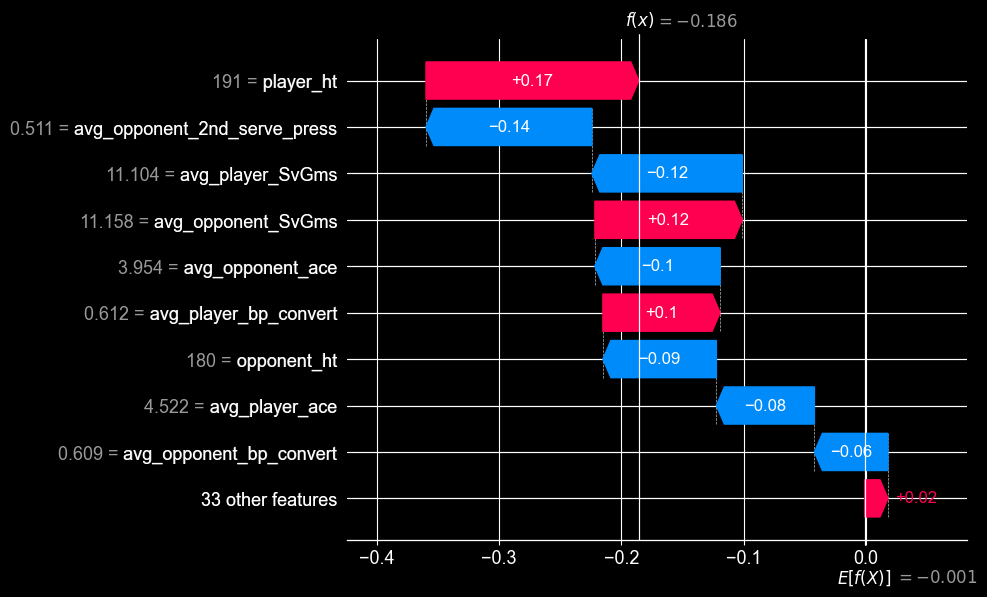

In [97]:
shap.plots.waterfall(shap_values[0])

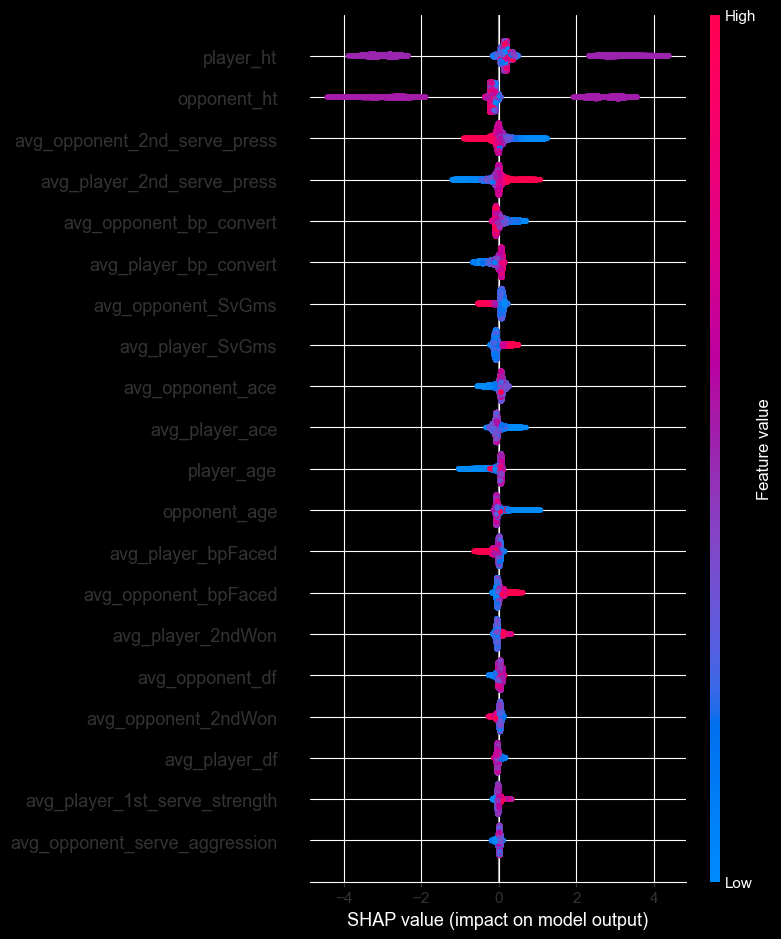

In [98]:
shap.summary_plot(shap_values, X_test)

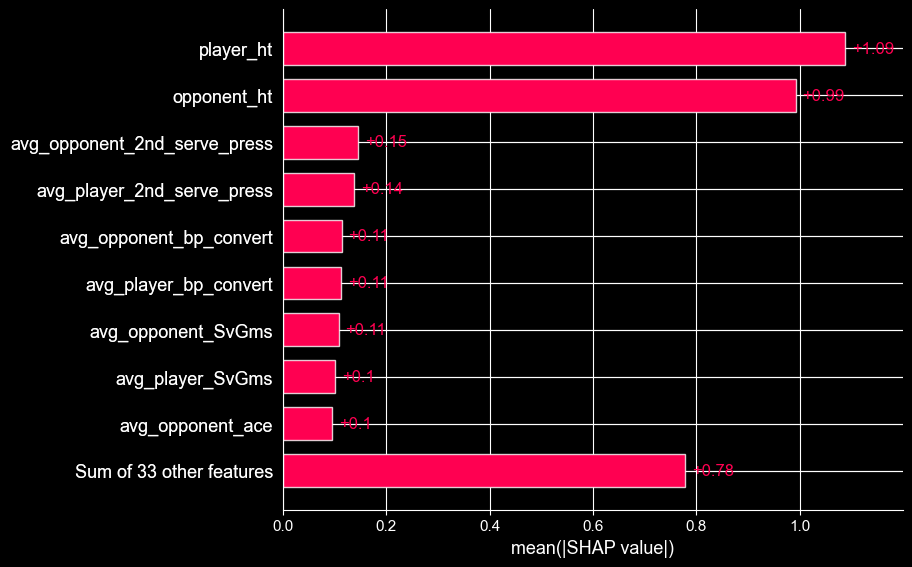

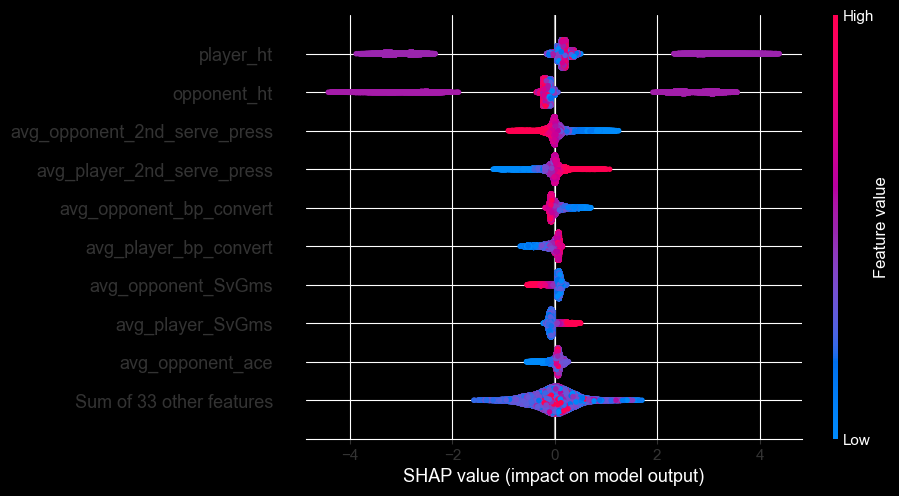

In [100]:
shap.plots.bar(shap_values)  # ranked bar chart
shap.plots.beeswarm(shap_values)  # shows feature impact distribution

In [102]:
import joblib
import json

joblib.dump(xgb, 'xgb_model.pkl')

feature_cols = X_train.columns.tolist()
with open('xgb_features.json', 'w') as f:
    json.dump(feature_cols, f)